In [1]:
using Pkg
Pkg.activate("/home/chrisstrong/MRI_Driving/inverse-feedback-games/")
using iLQGames
import iLQGames: dx
using Plots
using ForwardDiff
using iLQGames:
    SystemTrajectory
using iLQGames:
    LinearSystem
using Infiltrator
using Optim
using LinearAlgebra
using Distributed
using Dates
using Statistics


include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

# added imports by Chris 
ENV["PYTHON"] = "/home/chrisstrong/miniconda3/envs/brain_env"
Pkg.build("PyCall")
using PyCall
import Base.length
using BenchmarkTools
using LazySets
using LinearAlgebra
using Plots
using Random

include("../src/geometric_utils.jl")


  Activating project at `~/MRI_Driving/inverse-feedback-games`
    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/b19db3927f0db4151cb86d073689f2428e524576/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`


distance_and_projection (generic function with 1 method)

### Geometric utilities

#### Testing the geometric utilities

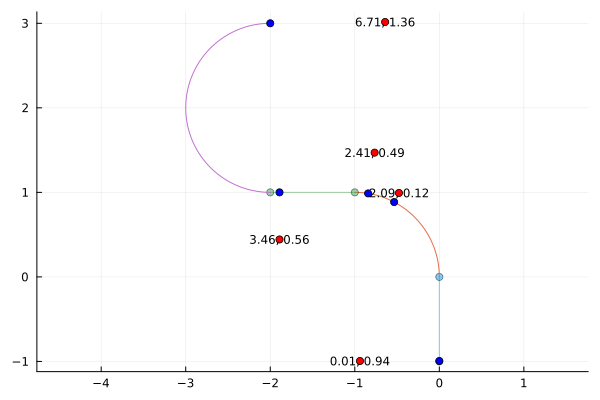

In [2]:
plot()
line_segment_1 = LineSegment([0., -1], [0., 0])
curve_1 = Arc([-1., 0], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 1], [-2., 1])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
visualize(trajectory)

# equal axis scale
plot!(aspect_ratio=:equal)


# benchmark time to project 1000 points onto the trajectory
points = [5 * rand(2) .- 1 for _ in 1:1000]
#@btime project(point, trajectory) setup=(point=3*rand(2) .- 1)

# generate random points, project onto trajectory 
num_points = 5
points = [[3 * rand(), 5 * rand()] - [3, 1] for _ in 1:num_points]

# for each point get its frenet coordinates and the point 
frenet_results = [project_frenet_coordinates(point, trajectory) for point in points]
distances_along_curve, distances_from_curve, projected_points = zip(frenet_results...)

for (point, distance_along_curve, distance_from_curve) in zip(points, distances_along_curve, distances_from_curve)
    scatter!([point[1]], [point[2]], color="red")
    # label each with distance along curve and distance from curve after rounding to 2 digits
    label = "$(round(distance_along_curve, digits=2)), $(round(distance_from_curve, digits=2))"
    annotate!([point[1]], [point[2]], text(label, 8, :black))
end

for point in projected_points
    scatter!([point[1]], [point[2]], color="blue")
end
# remove legend
plot!(legend=false)


### Data processing utils

In [3]:
function vehicle_index_to_col(index)
    return 6 + 5*(index - 1)
end

function pedestrian_index_to_col(index, k_closest_vehicles)
    return 6 + 5*k_closest_vehicles + 5*(index - 1)
end

function centerline_col(k_closest_vehicles, k_closest_pedestrians)
    return 6 + 5*k_closest_vehicles + 5*k_closest_pedestrians
end

function relu(x)
    return max.(0, x)
end

k_closest_vehicles = 15
k_closest_pedestrians = 0

0

### Visualization Utils

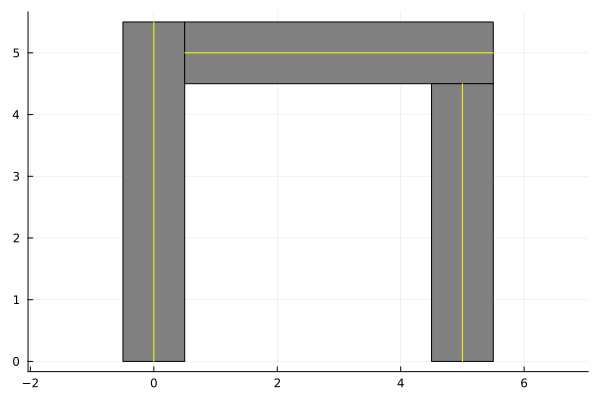

In [4]:
function visualize_road_segment(line_segment, road_width; color="gray", kwargs...)
    p, q = line_segment.p, line_segment.q
    v = p - q
    v = v / norm(v)

    perp = [0 -1; 1 0] * v
    rectangle_p1 = p + road_width / 2 * perp
    rectangle_p2 = p - road_width / 2 * perp
    rectangle_p3 = q - road_width / 2 * perp
    rectangle_p4 = q + road_width / 2 * perp
    plot!(polygon_from_points([rectangle_p1, rectangle_p2, rectangle_p3, rectangle_p4]); color=color, label="", kwargs...)
    
    # plot a yellow dashed line along the center and white lines along the edges 
    return plot!([p[1], q[1]], [p[2], q[2]], color="yellow", label="")
end

function visualize_map(centerlines, road_width=1200; kwargs...)
    for centerline in centerlines
        visualize_road_segment(centerline, road_width; kwargs...)
    end
    return plot!()
end

rectangle(w, h, x, y) = Shape(x + [0,w,w,0], y + [0,0,h,h])
polygon_from_points(points) = Shape([p[1] for p in points], [p[2] for p in points])

function visualize_road_from_key_points(key_points, road_width; kwargs...)
    # between each key point draw a rectangle of width road_width 
    for i in 1:length(key_points) - 1
        p1 = key_points[i]
        p2 = key_points[i + 1]

        v = p2 - p1
        v = v / norm(v)

        # extend line to be road_width / 2 longer 
        # except for the first and last lines
        if i > 1
            p1 = p1 + road_width / 2 * v
        end
        if i < length(key_points) - 1
            p2 = p2 + road_width / 2 * v
        end

        visualize_road_segment(LineSegment(p1, p2), road_width; kwargs...)
    end
    return plot!(aspect_ratio=:equal)
end

plot()
visualize_road_from_key_points([[0., 0], [0., 5], [5., 5], [5., 0]], 1.0, color="gray")

In [5]:
# load labels
# py"""
# import numpy as np 
# x = (np.load('/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_ids_k_closest_vehicles=15_k_closest_pedestrians=0.npy'))
# """

# y = py"x"
#train_ids = py"np.load('/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_ids_k_closest_vehicles=15_k_closest_pedestrians=0.npy')"

### Loading actual data

Load the trajectories

In [6]:
py"""
import pickle
 
def load_pickle(fpath):
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    return data
"""

load_pickle = py"load_pickle"

train_demonstrations_turns = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")
train_point_sequences = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_point_sequences.pkl")

# # also load the ones that are just straights 
# train_demonstrations = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")

94-element Vector{Vector{Vector{Float64}}}:
 [[72424.5, 54220.0], [42719.0, 54220.0], [42719.0, 10586.5]]
 [[42719.0, 9680.46], [42719.0, 1260.14]]
 [[0.0, 25913.6], [0.0, 40152.3]]
 [[2040.33, 41076.0], [8215.0, 41076.0], [8215.0, 32986.3]]
 [[8215.0, 30236.5], [8215.0, 25467.0], [16430.0, 25467.0], [16430.0, 46931.3]]
 [[16430.0, 47686.6], [16430.0, 25467.0], [25798.5, 25467.0]]
 [[26868.0, 25467.0], [8215.0, 25467.0], [8215.0, 28602.2]]
 [[8215.0, 31415.3], [8215.0, 32860.0], [16430.0, 32860.0], [16430.0, 25467.0], [1118.29, 25467.0]]
 [[0.0, 26362.1], [0.0, 28075.0]]
 [[0.0, 29180.700000000004], [0.0, 0.0], [10194.2, 0.0]]
 [[10090.1, 0.0], [0.0, 0.0], [0.0, 33194.09999999999]]
 [[0.0, 36963.8], [0.0, 41076.0], [16430.0, 41076.0], [16430.0, 39118.6]]
 [[16430.0, 38192.8], [16430.0, 54220.0], [18264.4, 54220.0]]
 ⋮
 [[5237.09, 91188.0], [19716.0, 91188.0], [19716.0, 78865.0], [26288.0, 78865.0], [26288.0, 54220.0], [40580.1, 54220.0]]
 [[41359.299999999996, 54220.0], [42719.0, 54220

Load centerlines

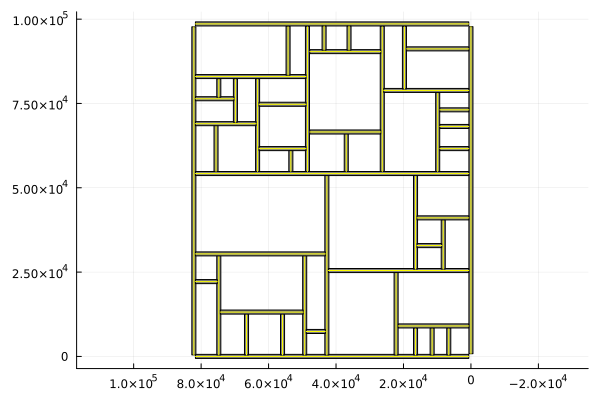

In [7]:
using NPZ
centerline_filename = "/data/fmri/full_dataset/map_centerlines.npz"
centerlines = npzread(centerline_filename)["lines"]
centerlines = [LineSegment(centerlines[i, 1, :], centerlines[i, 2, :]) for i in 1:size(centerlines, 1)]

plot()
visualize_map(centerlines, 1200, color="gray")
plot!(aspect_ratio=:equal, xflip=true)

Rescaling data

In [8]:
# Set some parameters
road_width_cm = 1200
scaling_factor = 2000

# Rescale the map
scaled_centerlines = [LineSegment(centerline.p / scaling_factor, centerline.q / scaling_factor) for centerline in centerlines]

# Rescale the train demonstration states 
train_demonstrations_turns_states = [train_demonstration[1] for train_demonstration in train_demonstrations_turns]

indices_to_scale = [1, 2, 4, 5] # x, y, v, a
for j = 1:k_closest_vehicles
    cur_col = vehicle_index_to_col(j)
    append!(indices_to_scale, [cur_col, cur_col + 1, cur_col + 3, cur_col + 4])
end 
centerline_index = centerline_col(k_closest_vehicles, k_closest_pedestrians)
append!(indices_to_scale, [centerline_index, centerline_index + 1, centerline_index + 2, centerline_index + 3])

scaled_demonstration_states = deepcopy(train_demonstrations_turns_states)
for i = 1:length(train_demonstrations_turns_states)
    scaled_demonstration_states[i][:, indices_to_scale] /= scaling_factor
end

# Scale the train_point_sequences 
scaled_train_point_sequences = train_point_sequences / scaling_factor

# Scale the road width
scaled_road_width = road_width_cm / scaling_factor


0.6

In [9]:
# Pull out some data from the first run to use for testing and visualization 
key_points = scaled_train_point_sequences[1]
xs = scaled_demonstration_states[1][:, 1]
ys = scaled_demonstration_states[1][:, 2];

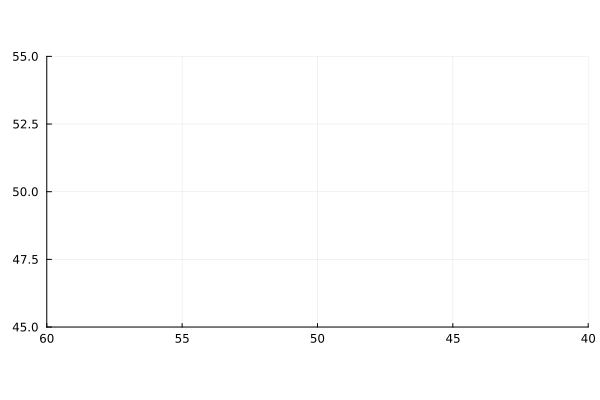

In [10]:
function road_shift_from_points(point1, point2, road_width)
    # Since we're using a left handed coordinate
    # if we're going in the positive x direction (left), the road shift is up in y 
    # if we're going in the negative x direction (right), the road shift is down in y 
    # if we're going in the positive y direction (up), the road shift is negative in x (right)
    # if we're going in the negative y direction (down), the road shift is positive in y (left)
    start_x, start_y, second_x, second_y = point1[1], point1[2], point2[1], point2[2]
    # assert x is constant or y is constant 
    @assert (start_x ≈ second_x || start_y ≈ second_y)

    if start_x < second_x
        road_shift = [0, road_width / 4]
    elseif start_x > second_x
        road_shift = [0, -road_width / 4]
    elseif start_y < second_y
        road_shift = [-road_width / 4, 0]
    elseif start_y > second_y
        road_shift = [road_width / 4, 0]
    end
    return road_shift
end

function shorten_segment(segment::LineSegment, dist_to_cut, direction="both")
    p, q = segment.p, segment.q
    v = q - p
    v = v / norm(v)
    if direction == "both"
        return LineSegment(p + v * dist_to_cut, q - v * dist_to_cut)
    elseif direction == "start"
        return LineSegment(p + v * dist_to_cut, q)
    elseif direction == "end"
        return LineSegment(p, q - v * dist_to_cut)
    else 
        error("Invalid direction")
    end
end 

function is_right_turn(direction_1, direction_2)
    # in left-handed coordinates, check to see if the turn is right. 
    # direction_1 should be the direction you start heading, and direction 2 should be the direction you end up heading 
    # if the cross product of the two vectors is positive, then it's a right turn
    return cross([direction_1; 0], [direction_2; 0])[3] > 0
end

function trajectory_plan_from_key_points(key_points, road_width)
    # go along alternating between straights and arcs, is that always right? 
    # we'll note that we're in a left handed coordinate system, so left is more positive xs and right is 

    trajectory_segments = []
    
    # From the first two points get a line 
    point1, point2 = key_points[1], key_points[2]
    road_shift = road_shift_from_points(point1, point2, road_width)
    line_segment = LineSegment(point1 + road_shift, point2 + road_shift)
    # shorten the end of the line segment by 0.5*road_width 
    line_segment = shorten_segment(line_segment, 0.5*road_width, "end")
    push!(trajectory_segments, line_segment)

    # now for each trio we'll add a curve then a straight 
    for i = 1:(length(key_points) - 2)
        point1, point2, point3 = key_points[i], key_points[i+1], key_points[i+2]

        # get the vector from point1 to point2
        direction_1 = (point1 - point2) / norm(point1 - point2)
        # get the vector from point2 to point3
        direction_2 = (point3 - point2) / norm(point3 - point2)

        # add on the segment from point 2 to point 3 
        road_shift = road_shift_from_points(point2, point3, road_width)
        line_segment = LineSegment(point2 + road_shift, point3 + road_shift)
        # shorten line segment on both sides by 0.5*road_width unless we're on the last index
        # in which case we just shorten the start and not the end  
        if i == length(key_points) - 2
            line_segment = shorten_segment(line_segment, 0.5*road_width, "start")
        else 
            line_segment = shorten_segment(line_segment, 0.5*road_width, "both")
        end

        right_turn = is_right_turn(-direction_1, direction_2)
        center_shift_amount = right_turn ? road_width / 2 : road_width / 4
        circle_center = point2 + center_shift_amount * direction_1 + center_shift_amount * direction_2
        
        # now see the angle from the end of the previous line segment to this circle 
        previous_line_segment = trajectory_segments[end]
        previous_end = previous_line_segment.q
        start_angle = atan(previous_end[2] - circle_center[2], previous_end[1] - circle_center[1])
        
        # now see the angle from the start of the next line segment to this circle 
        next_line_segment = line_segment
        next_start = next_line_segment.p
        end_angle = atan(next_start[2] - circle_center[2], next_start[1] - circle_center[1])

        clockwise = ~right_turn 
        if clockwise 
            # right turn in left-handed frame is a left turn, so larger radius 
            circle_radius = 3 * road_width / 4
        else 
            circle_radius = road_width / 4
        end
        arc = Arc(circle_center, circle_radius, start_angle, end_angle, clockwise)
        
        push!(trajectory_segments, line_segment)
        push!(trajectory_segments, arc)
    end
    
    return ListTrajectoryPlan(trajectory_segments)
end 

plot()
# plot the trajectory and key points 
visualize_road_from_key_points(key_points, scaled_road_width)
plot!(xs, ys, color="red", label="")
#scatter!(key_xs, key_ys, color="blue", label="")

# now visualize the plan 
trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
visualize(trajectory_plan, color="blue")

# axis equal 
plot!(aspect_ratio=:equal, xflip=true)
# set x limits and y limits 
plot!(xlims=(40, 60), ylims=(45, 55))

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/trajectory_from_data.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/trajectory_from_data.gif")
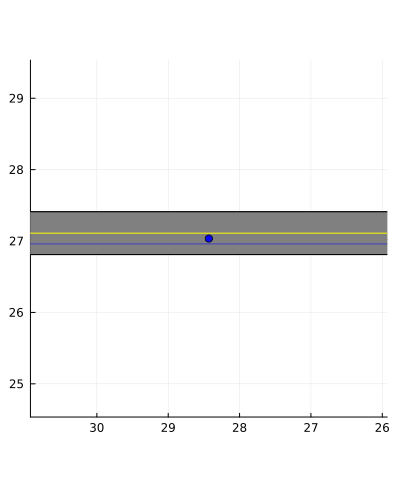

In [11]:
# animate the trajectory on the trajectory plan 
width_around_car = 5000 / scaling_factor 
height_around_car = 5000 / scaling_factor

anim=@animate for t in 500:5:900
    visualize_road_from_key_points(key_points, scaled_road_width, color="gray")

    # plot with a single circle the current location 
    scatter!([xs[t]], [ys[t]], color="blue", label="")

    # plot the plan 
    visualize(trajectory_plan, color="blue")

    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft, xflip=true)
    # set x limits and y limits
    plot!(xlims=(xs[t] - width_around_car, xs[t] + width_around_car), ylims=(ys[t] - height_around_car, ys[t] + height_around_car))
end
gif(anim, "visualizations/trajectory_from_data.gif", fps = 10)

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
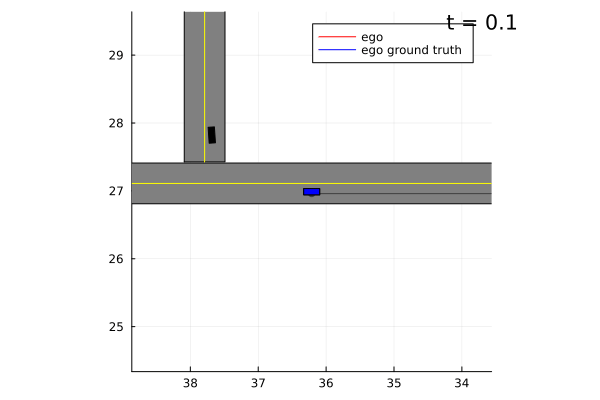

In [12]:
function plot_car_at_state(x, y, heading, velocity; width=185/scaling_factor, height=470/scaling_factor, color="black", kwargs...)
    # plot a rectangle at x, y, with given heading 

    front_right = [x + height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    front_left = [x + height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_left = [x - height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_right = [x - height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    
    # plot rectangle 
    plot!(polygon_from_points([front_right, front_left, back_left, back_right]), color=color, label="", kwargs...)
    # plot arrow from center in direction of heading 
    arrow_length = height*1.5
    arrow_delta_x = arrow_length * cos(heading)
    arrow_delta_y = arrow_length * sin(heading)
    #return quiver!([x], [y], quiver=([arrow_delta_x], [arrow_delta_y]), color=color, label="", kwargs...)
    #return plot!([x + arrow_delta_x, x], [y + arrow_delta_y, y], color=color, arrow=false, label="", kwargs...)
    return plot!()
end

function animate_trajectories(trajectories, colors, labels, demonstration, trajectory_plan, road_width, centerlines; time_spacing=5, field_of_view=5000, k_closest_vehicles=15, kwargs...)
    """
    trajectories: list of trajectories, each of which are a num_times x 4 array with x, y, heading, v
    """
    ego_states = demonstration[:, 1:4]

    # plot the vehicles from the trajectories
    anim = @animate for t = 1:time_spacing:size(demonstration, 1)
        plot(aspect_ratio=:equal, xflip=true)
        visualize_map(centerlines, road_width)
        # plot the trajectories 
        for (i, trajectory) in enumerate(trajectories)
            x, y, heading, v = trajectory[t, :]
            color = colors[i]
            label = labels[i]
            plot_car_at_state(x, y, heading, v, color=color)
            # also plot their trajectory so far
            plot!(trajectory[1:t, 1], trajectory[1:t, 2], color=color, label=label)
        end

        # visualize the trajectory plan 
        visualize(trajectory_plan, color="black")

        # plot the ground truth 
        x, y, heading, v = ego_states[t, :]
        plot_car_at_state(x, y, heading, v, color="blue")
        plot!(ego_states[1:t, 1], ego_states[1:t, 2], color="blue", label="ego ground truth")

        # plot the other vehicles 
        for i in 1:k_closest_vehicles
            other_x, other_y, other_heading, other_v = demonstration[t, vehicle_index_to_col(i):vehicle_index_to_col(i) + 3]
            plot_car_at_state(other_x, other_y, other_heading, other_v, color="black")
        end

        # set x limit based on the ego vehicle
        xlims = [x - field_of_view / 2, x + field_of_view / 2]
        ylims = [y - field_of_view / 2, y + field_of_view / 2]
        plot!(xlim=xlims, ylim=ylims)

        # add text label on the side showing t rounded to 2 digits  
        text_label = "t = $(round(t/15, digits=1))"
        annotate!(xlims[1], ylims[2], text_label)
    end
    return anim
end

demo = scaled_demonstration_states[1]
ego_traj = demo[:, 1:4]

trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
anim = animate_trajectories([ego_traj], ["red"], ["ego"], demo, trajectory_plan, scaled_road_width, scaled_centerlines, field_of_view = 10000/scaling_factor, time_spacing=10)
gif(anim, "visualizations/ego_trajectory.gif", fps=10)

### Combining the data with our planner

In [13]:
line_segment_1 = LineSegment([0., -1], [0., 5])
curve_1 = Arc([-1., 5], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 6], [-10., 6])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
# trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
test_trajectory_plan = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2])


ListTrajectoryPlan(Any[LineSegment{Float64, Vector{Float64}}([0.0, -1.0], [0.0, 5.0]), Arc([-1.0, 5.0], 1.0, 0.0, 1.5707963267948966, false), LineSegment{Float64, Vector{Float64}}([-1.0, 6.0], [-10.0, 6.0])])

In [14]:
nx, nu, ΔT, game_horizon = 4, 2, 1/15, 30

# setup the dynamics
struct SingleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2] )
dynamics = SingleUnicycle()

ego_v_desired = 600 / scaling_factor 

ego_weight_distance_along_curve = 0.01
ego_weight_distance_from_curve = 10.0
ego_weight_velocity = 5.0
ego_weight_control = 1.0 / (scaling_factor / 1000)^2
ego_weight_distance = 0.0

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    # get index of this time step 
    # round t / delta T to an int 
    t_index = round(Int, t / ΔT)

    # add in a cost given by the distance to the nearest vehicle 
    return -ego_weight_distance_along_curve * ego_distance_along_curve^2 + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2)
end

costs = (FunctionPlayerCost(ego_vehicle_cost),)
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
key_points = scaled_train_point_sequences[1]
trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
demo = scaled_demonstration_states[1]
demo = demo[1000:end, :] # cut off the static beginning

ego_traj = demo[:, 1:4]
x0 = SVector(demo[1, 1:4]...)
#x0 = SVector(0, 3.0, pi/2, 1)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: You are using the fallback linearization using ForwardDiff. Consider
│     implementing a custom `linearize` or `linearize_discrete` for your
│     `ControlSystem` type.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/control_system.jl:122
┌ Warning: You are using the fallback quadraticization using ForwardDiff.
│     Consider implementing a custom `quadraticize` for your `ControlSystem`
│     type.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/quadraticize.jl:8


(true, SystemTrajectory{30, 0.06666666666666667, 4, 2, SizedVector{30, SVector{4, Float64}, Vector{SVector{4, Float64}}}, SizedVector{30, SVector{2, Float64}, Vector{SVector{2, Float64}}}}(SVector{4, Float64}[[22.32215, 26.9962, -3.1408072554263957, 0.05048], [22.31637430117142, 26.996161259124737, -3.130409593721948, 0.12279559789336006], [22.30641157828224, 26.995998315490485, -3.1206484706127458, 0.17612723519085186], [22.293367155193163, 26.995664752755125, -3.1117040134146348, 0.21533468158055605], [22.278063845407733, 26.99514437280146, -3.1036660540265424, 0.24403119848203894], [22.261113997598716, 26.99444008946455, -3.0965621211946543, 0.26490407133442284], [22.242973188929444, 26.993565911703342, -3.0903776843562647, 0.2799525697186036], [22.223980245401254, 26.99254148367759, -3.085070667539379, 0.29066462691514416], [22.20438706513221, 26.991388548067746, -3.080581769680743, 0.29814804139290174], [22.184380835499265, 26.990128771974355, -3.076841745119579, 0.303227927106404

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
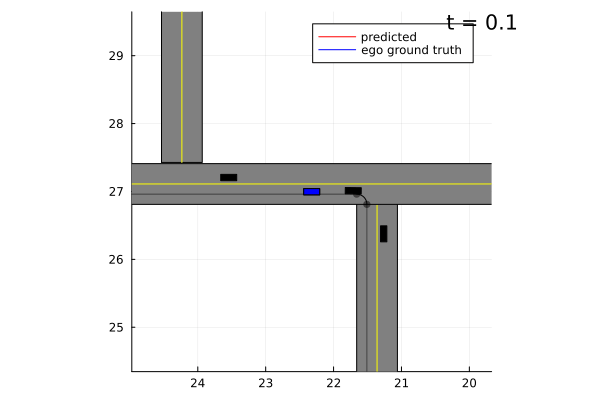

In [15]:
# visualize the results 
predicted_trajectory = zeros(game_horizon, 4)
predicted_trajectory[:, 1] = [expert_traj.x[t][1] for t in 1:game_horizon]
predicted_trajectory[:, 2] = [expert_traj.x[t][2] for t in 1:game_horizon]
predicted_trajectory[:, 3] = [expert_traj.x[t][3] for t in 1:game_horizon]
predicted_trajectory[:, 4] = [expert_traj.x[t][4] for t in 1:game_horizon]


anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[1:game_horizon, :], trajectory_plan, 1200 / scaling_factor, scaled_centerlines, field_of_view = 10000 / scaling_factor, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=15)


In [16]:
expert_traj.u

30-element SizedVector{30, SVector{2, Float64}, Vector{SVector{2, Float64}}} with indices SOneTo(30):
 [0.15596492556672117, 1.0847339684004007]
 [0.14641684663803667, 0.7999745594623766]
 [0.1341668579716629, 0.5881116958455627]
 [0.12056939082138146, 0.4304477535222435]
 [0.10655899247832143, 0.31309309278575825]
 [0.09276655257584225, 0.22572747576271107]
 [0.0796052522532935, 0.16068085794810805]
 [0.06733346787954185, 0.11225121716636319]
 [0.05610036841745893, 0.07619828570254215]
 [0.045978692126904724, 0.04936781135015711]
 [0.036988141823780296, 0.029412679155541285]
 [0.029111988855463563, 0.01458591640086887]
 [0.022308806294944777, 0.003587053836302881]
 ⋮
 [0.00023592045929818773, -0.021962692531940414]
 [-0.0010446354399192767, -0.02297238461833298]
 [-0.0018521859037746785, -0.023531014135106956]
 [-0.0022639868665921686, -0.023701812762789987]
 [-0.002355519311484095, -0.023513813180626675]
 [-0.002200419496509047, -0.022964235518862]
 [-0.0018704983003281917, -0.022018

In [17]:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")

cur_x = SVector(demo[1, 1:4]...)
num_steps = 240
xs = [SVector{length(cur_x)}(zeros(4)) for i = 1:(num_steps+1)]
xs[1] = cur_x
for t = 1:num_steps
    c, expert_traj, strategies = solve(g, solver, xs[t])
    if c == false 
        println("Solve failed, gave u: ", expert_traj.u[1])
    end
    
    first_u = expert_traj.u[1]
    #println("first u: ", first_u)
    xs[t+1] = xs[t] +  ΔT * dx(dynamics, xs[t], first_u, 0.)
end

predicted_trajectory = zeros(num_steps+1, 4)
[predicted_trajectory[i, :] = xs[i] for i in 1:num_steps+1];


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
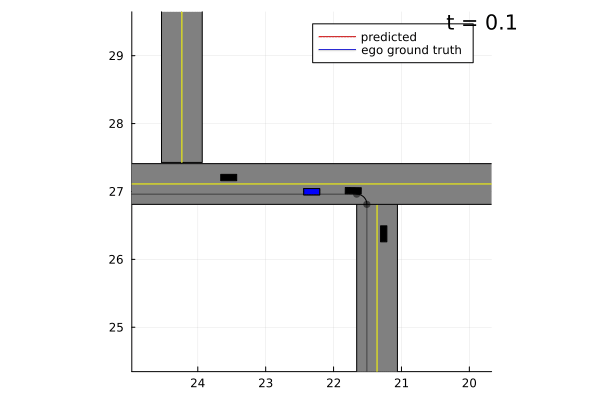

In [18]:
anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[1:num_steps+1, :], trajectory_plan, 1200 / scaling_factor, scaled_centerlines, field_of_view = 10000 / scaling_factor, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=15)

### Trying out with a cost for the other vehicles

In [41]:
# ego_v_desired = 800 / scaling_factor 
# ego_comfortable_distance = 1000 / scaling_factor 
# scaling_distance_from_curve = 3

# ego_weight_distance_along_curve = 0.0
# ego_weight_distance_from_curve = 90.0
# ego_weight_velocity = 30.0
# ego_weight_control_1 = 14.0 / (scaling_factor / 1000)^2 / (control_scaling)^2
# ego_weight_control_2 = 14.0 / (scaling_factor / 1000)^2 / (control_scaling)^2

# n_other_vehicles_for_cost = 3
# ego_weight_distance = 40.0

function sigmoid(x)
    if x > 0
        return 1/(1 + exp(-x))
    else 
        return exp(x)/(1 + exp(x))
    end
end

sigmoid (generic function with 1 method)

In [120]:
nx, nu, ΔT, game_horizon = 5, 2, 1/15, 30
angular_control_scaling = 1 # 3
velocity_control_scaling = 1 # 3

# setup the dynamics
struct SingleUnicycleTimeAugmented <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycleTimeAugmented, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1] / angular_control_scaling, u[2] / velocity_control_scaling, 0.0 ) # last element of state is the initial time 
dynamics = SingleUnicycleTimeAugmented()

# ego_v_desired = 800 / scaling_factor 
# ego_comfortable_distance = 900 / scaling_factor 
# scaling_distance_from_curve = 5

# ego_weight_distance_along_curve = 5.0
# ego_weight_distance_from_curve = 10.0
# ego_weight_velocity = 500.0
# ego_weight_control_1 = 2.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2
# ego_weight_control_2 = 40.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2

# ego_weight_distance = 2.0

# earlier copy of weights 

k_closest_vehicles_for_cost = 5

ego_v_desired = 600 / scaling_factor 

ego_weight_distance_along_curve = 0.02
ego_weight_distance_from_curve = 10.0
ego_weight_velocity = 5.0
ego_weight_control_1 = 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2
ego_weight_control_2 = 1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2

ego_comfortable_distance = 900 / scaling_factor 
scaling_distance_from_curve = 3.0
comfortable_distance_sigmoid_scaling = 10.0

ego_weight_distance = 1.0

distance_from_curve_sigmoid_scaling = 30.0 
distance_from_curve_sigmoid_center = 0.2

desired_velocity_sigmoid_scaling = 6.0
desired_velocity_sigmoid_threshold = ego_comfortable_distance


key_points = scaled_train_point_sequences[1]
trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 


demo = scaled_demonstration_states[1]
demo = demo[1000:end, :] # cut off the static beginning


function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v, start_time = x[1:5]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    cur_cost = 0
    # add on a cost based on the positions of the other vehicles
    # get index of this time step 
    # round t / delta T to an int 
    t_index = floor(Int, (start_time + t) / ΔT) + 1

    closest_car_in_front = Inf

    car_in_front_loc = nothing
    for i = 1:k_closest_vehicles_for_cost
        vehicle_col = vehicle_index_to_col(i)
        vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a = demo[t_index, vehicle_col:vehicle_col + 4]
        vehicle_distance_along_curve, vehicle_distance_from_curve = wrapper_fcn([vehicle_x, vehicle_y])
        
        cur_distance = sqrt(scaling_distance_from_curve*(vehicle_distance_from_curve - ego_distance_from_curve)^2 + (vehicle_distance_along_curve - ego_distance_along_curve)^2)
        cur_cost += ego_weight_distance * (ego_comfortable_distance - cur_distance)^2 * sigmoid(comfortable_distance_sigmoid_scaling*(ego_comfortable_distance - cur_distance))  #relu(ego_comfortable_distance - cur_distance)^2
        # println("vehicle x, vehicle y: ", (vehicle_x, vehicle_y))
        # println("vehicle distance along curve, dist from curve: ", (vehicle_distance_along_curve, vehicle_distance_from_curve))
        # println("distanc: ", cur_distance)

        diff_along_curve = vehicle_distance_along_curve - ego_distance_along_curve
        # tell if the vehicle is in front of you 
        if diff_along_curve > 0 && (abs((vehicle_theta - ego_phi) % (2*pi)) < pi/4)
            if diff_along_curve < closest_car_in_front
                car_in_front_loc = [vehicle_x, vehicle_y]
            end
            closest_car_in_front = min(closest_car_in_front, diff_along_curve)
        end
    end

    println("closest car in front: ", closest_car_in_front)
    println("t: ", t, " location: ", car_in_front_loc)

    # println("Closest car in front: ", closest_car_in_front)
    # println("comfortable distance: ", ego_comfortable_distance)


    v_desired_modified = ego_v_desired * sigmoid(desired_velocity_sigmoid_scaling * (closest_car_in_front - desired_velocity_sigmoid_threshold)) # 1 / (1 + exp(-sigmoid_scaling*(closest_car_in_front - sigmoid_threshold))) * ego_v_desired 
    #v_desired_modified = ego_v_desired

    # cost includind distance along curve, distance from curve, speed, and control cost 
    distance_from_curve_component = ego_weight_distance_from_curve * ego_distance_from_curve^2 * sigmoid(distance_from_curve_sigmoid_scaling*(ego_distance_from_curve - distance_from_curve_sigmoid_center))

    cur_cost += -ego_weight_distance_along_curve * ego_distance_along_curve^2 + distance_from_curve_component + ego_weight_velocity * (ego_v - v_desired_modified)^2 + ego_weight_control_1 * u[1]^2 +  ego_weight_control_2 * u[2]^2


    # 1 / (1 + exp(-distance)) * (v - v_desired) * 2
    # 1/ (1 + exp(-x))

    return cur_cost
end

costs = (FunctionPlayerCost(ego_vehicle_cost),)
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

start_index = 898
x0 = SVector(demo[start_index, 1:4]..., (start_index-1) * ΔT)
#x0 = SVector(0, 3.0, pi/2, 1)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


closest car in front: Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{typeof(ego_vehicle_cost)}, GeneralGame{Int64, Tuple{SVector{2, Int64}}, SingleUnicycleTimeAugmented, Tuple{FunctionPlayerCost{typeof(ego_vehicle_cost)}}}, SVector{2, Float64}, Float64}, Float64}}(Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{typeof(ego_vehicle_cost)}, GeneralGame{Int64, Tuple{SVector{2, Int64}}, SingleUnicycleTimeAugmented, Tuple{FunctionPlayerCost{typeof(ego_vehicle_cost)}}}, SVector{2, Float64}, Float64}, Float64}}(0.40704999999999814,-0.0,1.0,-0.0,-0.0,-0.0),Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{typeof(ego_vehicle_cost)}, GeneralGame{Int64, Tuple{SVector{2, Int64}}, SingleUnicycleTimeAugmented, Tuple{FunctionPlayerCost{typeof(ego_vehicle_cost)}}}, SVector{2, Float64}, Float64}, Float64}}(-0.0,-0.0,-0.0,-0.0,-0.0,-0.0),Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{typeof(ego_vehicle_cost)}, GeneralGame{Int64, Tuple{SVector{2, Int64}}

(true, SystemTrajectory{30, 0.06666666666666667, 5, 2, SizedVector{30, SVector{5, Float64}, Vector{SVector{5, Float64}}}, SizedVector{30, SVector{2, Float64}, Vector{SVector{2, Float64}}}}(SVector{5, Float64}[[21.466150000000003, 7.6429, -1.5708678852942282, 0.4633915, 59.8], [21.466150938139425, 7.613918294275297, -1.5706553567904227, 0.4060596738305427, 59.8], [21.466157196306106, 7.588367643140146, -1.5704432267351953, 0.36045988465185635, 59.8], [21.46616780408404, 7.565561935097941, -1.570215068000813, 0.3237114321079186, 59.8], [21.46618237450784, 7.544982076699324, -1.5699574202062523, 0.2936844762935717, 59.8], [21.466200862839823, 7.526233661467213, -1.5696585655716915, 0.26876825623931316, 59.8], [21.466223433601673, 7.509016276648592, -1.5693074709699257, 0.24775373480044255, 59.8], [21.466250389058473, 7.493099999841951, -1.5688928139697873, 0.22973525758503488, 59.8], [21.466282134379234, 7.4783074783751475, -1.5684019832246368, 0.21404141277095362, 59.8], [21.466319167533

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
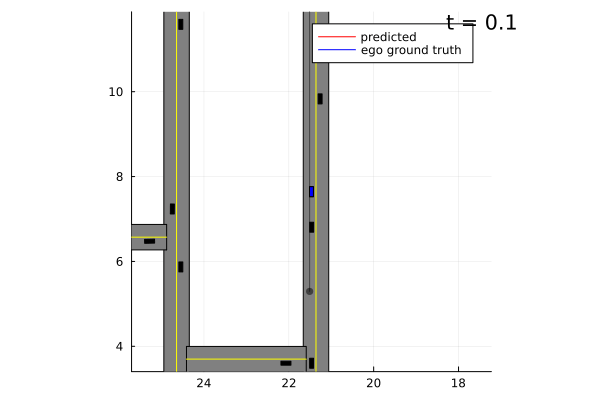

In [122]:
# visualize the results 
predicted_trajectory = zeros(game_horizon, 4)
predicted_trajectory[:, 1] = [expert_traj.x[t][1] for t in 1:game_horizon]
predicted_trajectory[:, 2] = [expert_traj.x[t][2] for t in 1:game_horizon]
predicted_trajectory[:, 3] = [expert_traj.x[t][3] for t in 1:game_horizon]
predicted_trajectory[:, 4] = [expert_traj.x[t][4] for t in 1:game_horizon]

anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[start_index:start_index + game_horizon - 1, :], trajectory_plan, 1200 / scaling_factor, scaled_centerlines, field_of_view = 16000 / scaling_factor, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=15)

In [112]:
solver = iLQSolver(g, max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE")

cur_x = SVector(demo[1, 1:4]..., 0.0)
num_steps = 600
xs = [SVector{length(cur_x)}(zeros(5)) for i = 1:(num_steps+1)]
xs[1] = cur_x
for iteration = 1:num_steps
    c, expert_traj, strategies = solve(g, solver, xs[iteration])
    if c == false 
        print(" ", iteration, " ")
        println("Solve failed, gave u: ", expert_traj.u[1])
        break
    end
    
    first_u = expert_traj.u[1]
    #println("first u: ", first_u)
    xs[iteration+1] = xs[iteration] +  ΔT * dx(dynamics, xs[iteration], first_u, 0.)
    # update the last state, which is a slack variable to deal with the global time 
    xs[iteration+1] = SVector(xs[iteration+1][1], xs[iteration+1][2], xs[iteration+1][3], xs[iteration+1][4], xs[iteration+1][5] + ΔT) 

end

predicted_trajectory = zeros(num_steps+1, 4)
[predicted_trajectory[i, :] = xs[i][1:4] for i in 1:num_steps+1];

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


 369 Solve failed, gave u: [0.03931952406653283, -0.11406097098143618]


┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
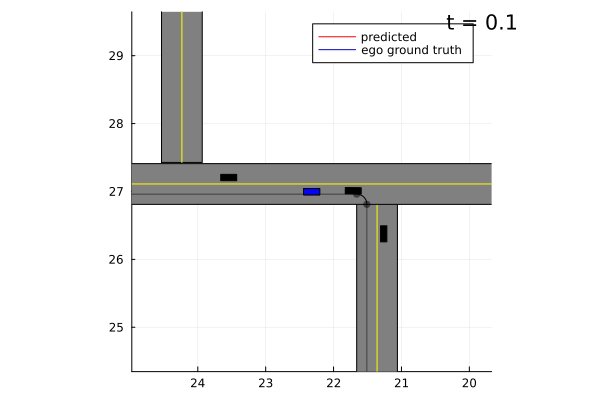

In [113]:
anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[1:num_steps+1, :], trajectory_plan, 1200 / scaling_factor, scaled_centerlines, field_of_view = 10000 / scaling_factor, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=30)

In [24]:
# check to see if initialize at each state in the demo if you can solve the problem if we'll still run into convergence issues. 
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.5, equilibrium_type="FBNE")

num_steps = 1000
for iteration = 1:num_steps
    cur_x = SVector(demo[iteration, 1:4]..., (iteration - 1) * ΔT) 
    c, expert_traj, strategies = solve(g, solver, cur_x)
    if c == false 
        print(" ", iteration, " ")
        println("Solve failed, gave u: ", expert_traj.u[1])
    end
    #print("u: ", expert_traj.u[1])

end

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


 906 Solve failed, gave u: [0.3574656949894348, -0.43128255921947256]
 907 Solve failed, gave u: [0.22019472372171398, -0.4064341059969954]


### Gradient calculation

In [25]:
function parameterized_cost(θ::Vector)

    ego_weight_distance_along_curve = θ[1]

    function ego_vehicle_cost(g, x, u, t)
        # cost for ego vehicle
        ego_x, ego_y, ego_phi, ego_v, start_time = x[1:5]
        ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

        cur_cost = 0
        # add on a cost based on the positions of the other vehicles
        # get index of this time step 
        # round t / delta T to an int 
        t_index = floor(Int, (start_time + t) / ΔT) + 1

        closest_car_in_front = Inf

        for i = 1:3
            vehicle_col = vehicle_index_to_col(i)
            vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a = demo[t_index, vehicle_col:vehicle_col + 4]
            vehicle_distance_along_curve, vehicle_distance_from_curve = wrapper_fcn([vehicle_x, vehicle_y])
            
            cur_distance = sqrt(scaling_distance_from_curve*(vehicle_distance_from_curve - ego_distance_from_curve)^2 + (vehicle_distance_along_curve - ego_distance_along_curve)^2)
            cur_cost += ego_weight_distance * relu(ego_comfortable_distance - cur_distance)^2
            # println("vehicle x, vehicle y: ", (vehicle_x, vehicle_y))
            # println("vehicle distance along curve, dist from curve: ", (vehicle_distance_along_curve, vehicle_distance_from_curve))
            # println("distanc: ", cur_distance)

            diff_along_curve = vehicle_distance_along_curve - ego_distance_along_curve
            # tell if the vehicle is in front of you 
            if diff_along_curve > 0 && (abs((vehicle_theta - ego_phi) % (2*pi)) < pi/4)
                closest_car_in_front = min(closest_car_in_front, diff_along_curve)
            end
        end

        sigmoid_scaling = 6.0
        sigmoid_threshold = ego_comfortable_distance
        v_desired_modified = 1 / (1 + exp(-sigmoid_scaling*(closest_car_in_front - sigmoid_threshold))) * ego_v_desired 
        #v_desired_modified = ego_v_desired

        # cost includind distance along curve, distance from curve, speed, and control cost 
        cur_cost += -ego_weight_distance_along_curve * ego_distance_along_curve^2 + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - v_desired_modified)^2 + ego_weight_control_1 * u[1]^2 +  ego_weight_control_2 * u[2]^2


        # 1 / (1 + exp(-distance)) * (v - v_desired) * 2
        # 1/ (1 + exp(-x))

        return cur_cost
    end

    return (FunctionPlayerCost(ego_vehicle_cost),)
end

parameterized_cost (generic function with 1 method)

In [26]:
function loss(θ, dynamics, expert_traj; gradient_mode = true, specified_solver_and_traj = false, 
                nominal_solver=[], nominal_traj=[], obs_time_list = 1:game_horizon-1, 
                obs_state_list = 1:nx, obs_control_list = 1:nu, no_control=false, x0_mode=false, x0=[]) 
    
    #tmp1 = transpose(mapreduce(permutedims, vcat, Vector([Vector(expert_traj.x[t][obs_state_list]) for t in obs_time_list])))
    

    if gradient_mode == false
        nominal_game = GeneralGame(game_horizon, player_inputs, dynamics, parameterized_cost(ForwardDiff.value.(θ)))
        nominal_solver = iLQSolver(nominal_game, max_scale_backtrack=10, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
        nominal_converged, nominal_traj, nominal_strategies = solve(nominal_game, nominal_solver, x0)
        
        # predicted_traj = zeros(game_horizon-1, 4)
        # predicted_traj[:, 1] = [nominal_traj.x[t][1] for t in 1:game_horizon-1]
        # predicted_traj[:, 2] = [nominal_traj.x[t][2] for t in 1:game_horizon-1]
        # predicted_traj[:, 3] = [nominal_traj.x[t][3] for t in 1:game_horizon-1]
        # predicted_traj[:, 4] = [nominal_traj.x[t][4] for t in 1:game_horizon-1]
        #tmp2 = transpose(mapreduce(permutedims, vcat, Vector([Vector(nominal_traj.x[t][obs_state_list]) for t in obs_time_list])))    
        
        loss_value = sum([nominal_traj.x[t][i] - expert_traj[t, i]] for t in 1:game_horizon - 1 for i = 1:4)
        return loss_value, nominal_traj, nominal_strategies, nominal_solver
    
    
    
    else
        if specified_solver_and_traj == false
            nominal_game = GeneralGame(game_horizon, player_inputs, dynamics, parameterized_cost(ForwardDiff.value.(θ)))
            nominal_solver = iLQSolver(nominal_game, max_scale_backtrack=10, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
            nominal_converged, nominal_traj, nominal_strategies = solve(nominal_game, nominal_solver, x0)
        end
        costs = parameterized_cost(θ)
        game = GeneralGame(game_horizon, player_inputs, dynamics, costs)
        lqg = Differentiable_Solvers.lq_approximation(game, nominal_traj, nominal_solver)
        traj = Differentiable_Solvers.trajectory(x0, game, Differentiable_Solvers.solve_lq_game_FBNE(lqg), nominal_traj)

        # predicted_traj = zeros(game_horizon-1, 4)
        # predicted_traj[:, 1] = [traj.x[t][1] for t in 1:game_horizon-1]
        # predicted_traj[:, 2] = [traj.x[t][2] for t in 1:game_horizon-1]
        # predicted_traj[:, 3] = [traj.x[t][3] for t in 1:game_horizon-1]
        # predicted_traj[:, 4] = [traj.x[t][4] for t in 1:game_horizon-1]


        loss_value = sum([traj.x[t][i] - expert_traj[t, i] for t in 1:game_horizon - 1 for i = 1:4])

        #loss_value = norm(predicted_traj-expert_traj )^2
        println("lost value: ", loss_value)
        return loss_value
    end
end



θ = [0.0]
x0 = SVector(demo[1, 1:4]..., 0.0)
loss(θ, dynamics, demo[1:game_horizon-1, 1:4], gradient_mode=true, x0=x0)

#grad = ForwardDiff.gradient(x -> loss(x, dynamics, demo[1:game_horizon-1, 1:4], gradient_mode=true, x0=x0), θ)
losses = []
θs = []
step_size = 0.0002
for i = 1:100
    cur_loss = loss(θ, dynamics,  demo[1:game_horizon-1, 1:4], gradient_mode=false, x0=x0)[1][1]
    push!(losses, cur_loss)
    push!(θs, θ)

    println("θ = ", θ, " loss = ", cur_loss)
    grad = ForwardDiff.gradient(x -> loss(x, dynamics, demo[1:game_horizon-1, 1:4], gradient_mode=true, x0=x0), θ)
    println("grad: ", grad)
    θ = θ - grad * step_size
end
# gradient_value = ForwardDiff.gradient(x -> loss(x,iLQGames.dynamics(g), equilibrium_type, expert_traj, true, true, current_solver, current_traj,
#                                                                         obs_time_list, obs_state_list, obs_control_list, no_control), θ)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


lost value: 1.5545044112541693


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


θ = [0.0] loss = 1.4182950877421565


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


...

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not chec

lost value: Dual{ForwardDiff.Tag{var"#176#177", Float64}}(0.7280715104248158,20.288470498226236)
grad: [20.288470498226236]
θ = [0.03669945976421944] loss = 0.7109734216608377
lost value: Dual{ForwardDiff.Tag{var"#176#177", Float64}}(0.7525484057814102,-20.28847049822585)
grad: [-20.28847049822585]
θ = [0.04075715386386461] loss = 0.6423230266633437
lost value: Dual{ForwardDiff.Tag{var"#176#177", Float64}}(0.728071510424809,20.28847049822618)
grad: [20.28847049822618]


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not chec

θ = [0.03669945976421937] loss = 0.7109734216608321
lost value: Dual{ForwardDiff.Tag{var"#176#177", Float64}}(0.7525484057814145,-20.28847049822587)
grad: [-20.28847049822587]
θ = [0.04075715386386455] loss = 0.6423230266633396
lost value: Dual{ForwardDiff.Tag{var"#176#177", Float64}}(0.728071510424805,20.288470498226104)
grad: [20.288470498226104]


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not chec

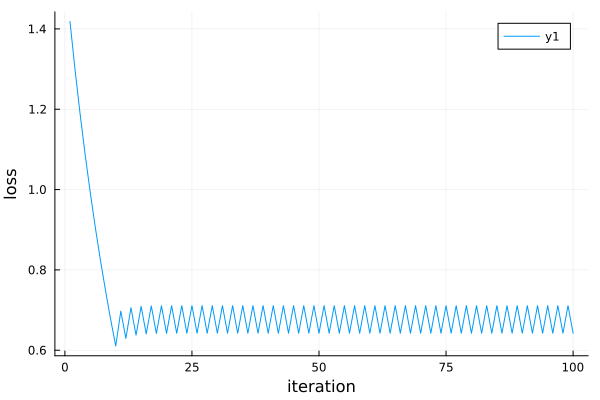

In [27]:
plot(losses, ylabel="loss", xlabel="iteration")


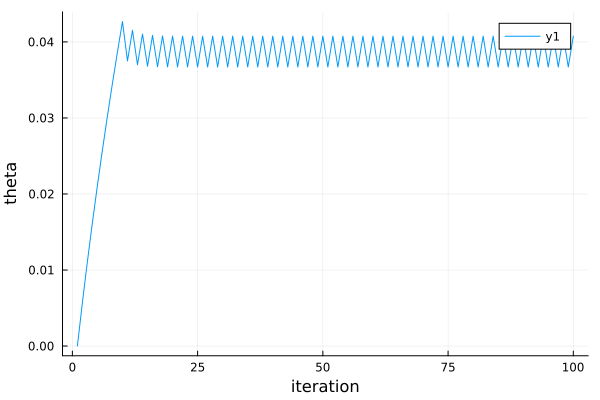

In [28]:
plot([theta[1] for theta in θs], ylabel="theta", xlabel="iteration")


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
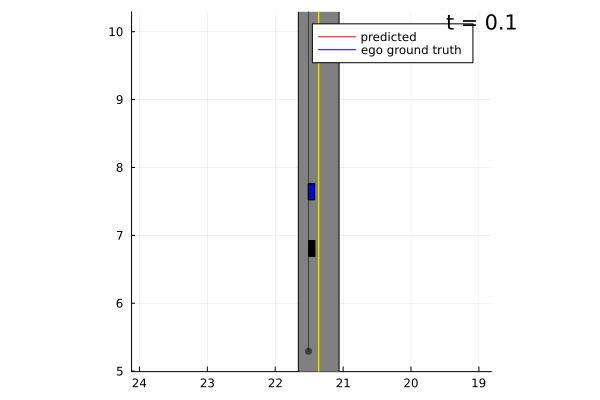

In [29]:
costs = parameterized_cost(θs[end])
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

start_index = 898
x0 = SVector(demo[start_index, 1:4]..., (start_index-1) * ΔT)
#x0 = SVector(0, 3.0, pi/2, 1)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)
predicted_trajectory = zeros(game_horizon, 4)
predicted_trajectory[:, 1] = [expert_traj.x[t][1] for t in 1:game_horizon]
predicted_trajectory[:, 2] = [expert_traj.x[t][2] for t in 1:game_horizon]
predicted_trajectory[:, 3] = [expert_traj.x[t][3] for t in 1:game_horizon]
predicted_trajectory[:, 4] = [expert_traj.x[t][4] for t in 1:game_horizon]

anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[start_index:start_index + game_horizon - 1, :], trajectory_plan, 1200 / scaling_factor, scaled_centerlines, field_of_view = 10000 / scaling_factor, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=15)

### Testing the Solver

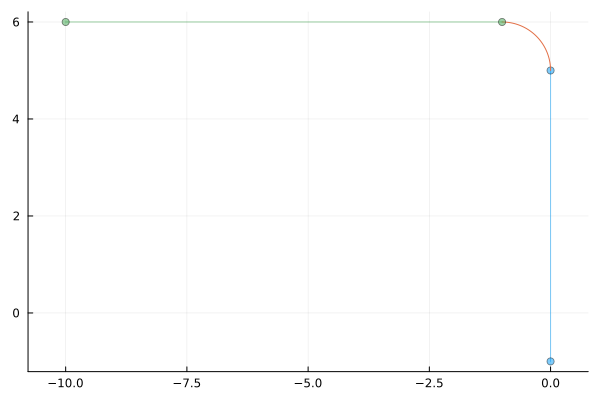

In [30]:
# trajectory to try to get it to track 
plot()
line_segment_1 = LineSegment([0., -1], [0., 5])
curve_1 = Arc([-1., 5], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 6], [-10., 6])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
# trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
trajectory_plan = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2])

visualize(trajectory_plan)
plot!(aspect_ratio=:equal)

#### Two Players

In [31]:
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end

# setup the dynamics
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()

# some parameters for the cost function 
ego_v_desired = 1.5
other_v_desired = 1.0
ego_comfortable_distance = 0.5

ego_weight_distance_along_curve = 1.0
ego_weight_distance_from_curve = 60.0
ego_weight_velocity = 5.0
ego_weight_control = 1.0
ego_weight_distance = 100.0

other_weight_distance_along_curve = 1.0
other_weight_distance_from_curve = 30.0
other_weight_velocity = 10.0
other_weight_control = 1.0



function distance_within_arc(point, arc)
    #arc = Arc([-9., 0.], 10., 0., pi/2, false)
    # assume we're inside the arc 

    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    if arc.start_angle <= angle <= arc.end_angle
        return arc.radius - norm(point - arc.center)
    else 
        # find the two endpoints of the arc, return the minimum distance to them 
        start_vertex = arc.center .+ arc.radius * [cos(arc.start_angle), sin(arc.start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(arc.end_angle), sin(arc.end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        return min(distance_start_vertex, distance_end_vertex)
    end
end

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

# Define the cost functions for each player 
function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
    distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
end
    
function other_vehicle_cost(g, x, u, t)
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

    #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
    return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
end

costs = (FunctionPlayerCost(ego_vehicle_cost), FunctionPlayerCost(other_vehicle_cost))

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
ego_x_0 = 0.5

x0 = SVector(0.0, 2.5, pi/2, 1,       0.0, 4, pi/2, 1,         0.2)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
# solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
# c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


9-element SVector{9, Float64} with indices SOneTo(9):
 0.0
 2.5
 1.5707963267948966
 1.0
 0.0
 4.0
 1.5707963267948966
 1.0
 0.2

In [32]:
# # Visualize the results 
# agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
# agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

# agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
# agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]

# anim=@animate for t in 1:game_horizon
#     plot(agent1_x, agent1_y, color="red", label="")
#     plot!(agent2_x, agent2_y, color="blue", label="")
#     scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
#     scatter!([agent2_x[t]], [agent2_y[t]], label="other", legend=:topleft, color="blue")
#     plot!(size=(400,500))
#     plot!(aspect_ratio=:equal, legend=:topleft)
#     visualize(trajectory_plan)
#     plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)
# end
# save_file = string("visualizations/example_turning_vs=[",  ego_v_desired, ", ", other_v_desired, "]_comfortabledist=", ego_comfortable_distance, ".gif")
# gif(anim, save_file, fps = 5)


In [33]:
# # Define the cost functions for each player 
# function ego_vehicle_cost(g, x, u, t, theta)
#     # cost for ego vehicle
#     ego_x, ego_y, ego_phi, ego_v = x[1:4]
#     other_x, other_y, other_phi, other_v = x[5:8]
#     desired_x = x[9]
#     ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

#     distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
#     distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

#     ego_weight_distance_along_curve = theta[1]
#     return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
# end
    
# function other_vehicle_cost(g, x, u, t, theta)
#     ego_x, ego_y, ego_phi, ego_v = x[1:4]
#     other_x, other_y, other_phi, other_v = x[5:8]
#     desired_x = x[9]
#     other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

#     #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
#     return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
# end

# function parameterized_cost(theta)
#     return (FunctionPlayerCost(g, x, u, t -> ego_vehicle_cost(g, x, u, t, theta)), FunctionPlayerCost(g, x, u, t -> other_vehicle_cost(g, x, u, t, theta)))
# end

### Single player

In [34]:
nx, nu, ΔT, game_horizon = 4, 2, 0.1, 40

# setup the dynamics
# UNCOMMENT THIS TO RUN 
#struct SingleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2] )
dynamics = SingleUnicycle()

other_vehicle_prediction = [] # TODO: fill in prediction here 

function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    # get index of this time step 
    # round t / delta T to an int 
    t_index = round(Int, t / ΔT)


    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2)
end

costs = (FunctionPlayerCost(ego_vehicle_cost),)
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(0, 3.0, pi/2, 1)


# if we want to solve an LQ game, then consider running the following 2 lines of codes:
# solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
# c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


4-element SVector{4, Float64} with indices SOneTo(4):
 0.0
 3.0
 1.5707963267948966
 1.0

In [35]:
# # visualize the results 
# agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]

# agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

# anim=@animate for t in 1:game_horizon
#     plot(agent1_x, agent1_y, color="red", label="")
#     scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
#     plot!(size=(400,500))
#     plot!(aspect_ratio=:equal, legend=:topleft)
#     visualize(trajectory_plan)
#     plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)
# end
# save_file = string("visualizations/example_singleagent_turning.gif")
# gif(anim, save_file, fps = 5)